# Inputs

In [3]:
# Inputs
row_reference = 120 #row index of reference for the interpolation of the spectral images
idx_spectral_image = 3 #index of the spectral image that will be plot in this notebook

# Import libraries, packages, functions, variables...

In [4]:
# import packages
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import datetime as dt
from astropy.io import fits
import matplotlib.patches as patches
from scipy.odr import Model, RealData, ODR
from scipy.interpolate import interp1d
import matplotlib.lines as mlines
import sunpy.map
from astropy.coordinates import SkyCoord
from sunpy.coordinates import frames
import astropy.units as u
import pandas as pd
from scipy.ndimage import gaussian_filter1d

import sys
import os
sys.path.append(os.path.abspath('..'))
from auxiliar_functions.data_path import path_data_soho 
from auxiliar_functions.SOHO_aux_functions import *
from auxiliar_functions.calibration_parameters__output import *
from auxiliar_functions.spectroheliogram_functions import *
from auxiliar_functions.solar_rotation_variables import *
from auxiliar_functions.aux_functions import *
from auxiliar_functions.general_variables import *


/tmp/ipykernel_9328/377542608.py:8: DeprecationWarning: `scipy.odr` is deprecated as of version 1.17.0 and will be removed in SciPy 1.19.0. Please use `https://pypi.org/project/odrpack/` instead.
  from scipy.odr import Model, RealData, ODR
/home/mario/anaconda3/envs/phd/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Functions for interpolation

### Uncertainty of linear interpolation

According to the paper [Propagation of Uncertainty and Comparison of Interpolation Schemes (White 2017)](https://link.springer.com/article/10.1007/s10765-016-2174-6), the formula of the uncertainty for linear interpolation is:

$$
\Delta y = \sqrt{ \left(\frac{x-x_2}{x_1-x_2} \Delta y_1 \right)^2 + \left(\frac{x-x_1}{x_2-x_1} \Delta y_2\right)^2 }
$$

where $x_1$ and $x_2$ are the two points neighbouring $x$ ($x_1 \le x \le x_2$).

This formula applies the error propagation to:

$$
y(x) = y_1 \frac{x-x_2}{x_1-x_2} + y_2 \frac{x-x_1}{x_2-x_1}
$$

Next function finds the uncertainty of an interpolant (y-axis uncertainty of the interpolated point).
Returns np.nan if x_interp is outside the range of x_data.

In [5]:
# One point:
def unc_linear_interpolation_1point(x_interp, x_data, y_unc_data):
    """
    This function finds the uncertainty of an interpolant (y-axis uncertainty of the interpolated point).
    Returns np.nan if x_interp is outside the range of x_data.
    """
    if x_interp < x_data[0] or x_interp > x_data[-1]:
        return np.nan  # Out of bounds

    # Find the index where x_interp would fit in x_data
    idx = np.searchsorted(x_data, x_interp)

    # Handle case where x_interp is exactly the first x_data point
    if idx == 0:
        return y_unc_data[0]

    # Get surrounding x and y-unc values
    x1 = x_data[idx - 1]
    x2 = x_data[idx]
    y1_unc = y_unc_data[idx - 1]
    y2_unc = y_unc_data[idx]

    # Linear interpolation for uncertainty
    A = (x_interp - x2) / (x1 - x2) * y1_unc
    B = (x_interp - x1) / (x2 - x1) * y2_unc
    y_unc_interp = np.sqrt(A**2 + B**2)

    return y_unc_interp

# Set of points (for example 1 row of the spectral image)
def linear_interpolation_setpoints(x_interp_list, x_data, y_data, y_unc_data): #(list, list, list)
    """
    This function finds the intensities and uncertainties of a set of interpolants (y-axis uncertainties of the interpolated points).
    Inputs:
        - x_interp_list: independent variable whose y-values should be found using the interpolation. 
        - x_data: x-axis values to interpolate.
        - y_data: y-axis data corresponding to the x_data values.
        - y_unc_data: uncertainties of y_data.
    """
    
    # Calculate uncertainties
    y_unc_interp_list = []
    for x_interp_i in x_interp_list:
        y_unc_interp_i = unc_linear_interpolation_1point(x_interp=x_interp_i, x_data=x_data, y_unc_data=y_unc_data)
        y_unc_interp_list.append(y_unc_interp_i)
    y_unc_interp = np.array(y_unc_interp_list)
    
    # Calculates intensities
    ## Convert masked values to NaNs:
    y_data = np.ma.filled(y_data, np.nan)
    y_unc_data = np.ma.filled(y_unc_data, np.nan)
    ## Interpolate the intensities
    interp_func = interp1d(x_data, y_data, kind='linear', bounds_error=False, fill_value=np.nan) #Create an interpolation function
    y_interp = interp_func(x_interp_list)
    
    return [y_interp, y_unc_interp]


### Check previous functions with an example

In [6]:
# We create some data, so this is not from SUMER or another instrument
slope_cal, intercept_cal = 0.042, 1530.48
y_data = np.array([0.56613697, 0.39293594, 0.4, 0.40808166, 0.53880121, 0.73620929, 0.97060608, 1.19321646, 1.36710772, np.nan, 1.42564009, 1.37180461, 1.25776281, 1.07025248, 0.81228781, 0.56613697, 0.39293594, 0.4, 0.43, 0.35, 0.545, 0.56613697, 0.39293594, 0.4])
y_unc_data = 0.1 * y_data
x_data = slope_cal * np.arange(0,len(y_data)) + intercept_cal
x_interp = [1530.742, 1530.954, 1531.055, 1531.064]

y_interp, y_unc_interp = linear_interpolation_setpoints(x_interp_list=x_interp, x_data=x_data, y_data=y_data, y_unc_data=y_unc_data)


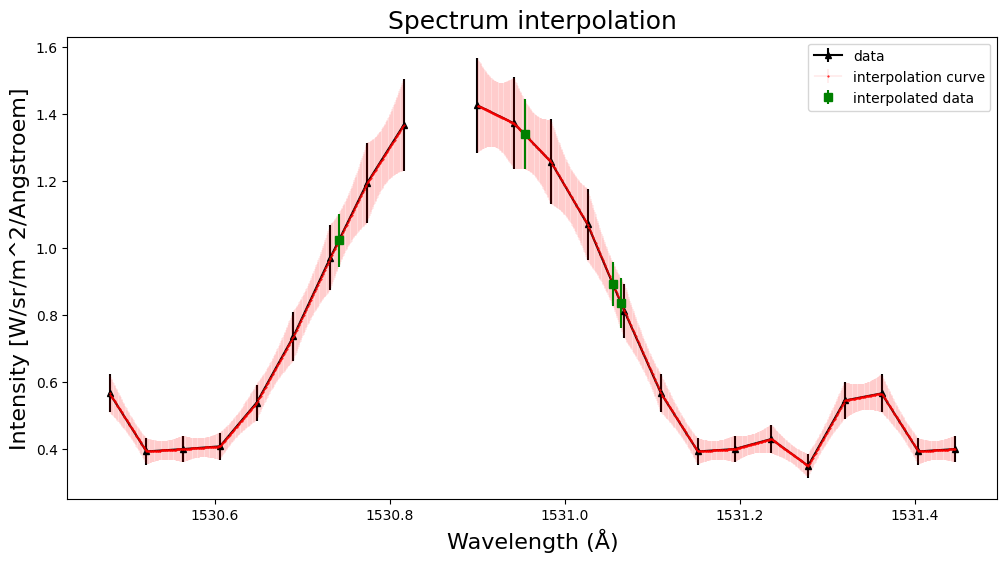

In [7]:
# We plot the data and interpolation to check that it makes sense
x_interp_curve = np.linspace(min(x_data), max(x_data), 50*len(x_data))
y_interp_curve, y_unc_interp_curve = linear_interpolation_setpoints(x_interp_list=x_interp_curve, x_data=x_data, y_data=y_data, y_unc_data=y_unc_data)


fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(12, 6))
ax.errorbar(x=x_data, y=y_data , yerr=y_unc_data , color='black', linewidth=1.5, marker='^', markersize=5, label='data')
ax.errorbar(x=x_interp_curve, y=y_interp_curve, yerr=y_unc_interp_curve, color='red', linewidth=0.1, marker='.', markersize=1, label='interpolation curve')
ax.errorbar(x=x_interp, y=y_interp, yerr=y_unc_interp, color='green', linewidth=0, elinewidth=1.5, markersize=6, marker='s', label='interpolated data')
ax.set_title(f'Spectrum interpolation', fontsize=18)
ax.set_xlabel('Wavelength (\u212B)', color='black', fontsize=16)
ax.set_ylabel(f'Intensity [W/sr/m^2/Angstroem]', color='black', fontsize=16)
ax.legend(fontsize=10)
plt.show(block=False)

### Apply functions above to all the rows of an spectral image

In [8]:
def calibration_spectral_image_interpolate(row_reference, spectral_image, spectral_image_unc, slope_list, slope_unc_list, intercept_list, intercept_unc_list):   
    """
    Interpolate all the rows of an spectral image.
    """
    def linear_func(x, m, b): return m*x+b
    def linear_func_uncertainty(x, dx, m, dm, b, db): return np.sqrt( (m*dx)**2 + (x*dm)**2 + db**2 )

    N_rows, N_cols = spectral_image.shape
    reference_wavelength = linear_func(x=np.arange(0,N_cols), m=slope_list[row_reference], b=intercept_list[row_reference]) #convert pixels to wavelengh
    unc_reference_wavelength = linear_func_uncertainty(x=np.arange(0,N_cols), dx=np.zeros(N_cols), m=slope_list[row_reference], dm=slope_unc_list[row_reference], b=intercept_list[row_reference], db=intercept_unc_list[row_reference])
    px_half = 0.5*slope_list[row_reference]
    extent_reference_wavelength = [reference_wavelength[0]-px_half, reference_wavelength[-1]+px_half]
    
    intensity_interpolated, intensity_unc_interpolated = [],[]
    for i_row in range(0,N_rows):
        wavelength_centerpixel_1row = linear_func(x=np.arange(0,N_cols), m=slope_list[i_row], b=intercept_list[i_row]) #convert pixels to wavelengh
        y_interp, y_unc_interp = linear_interpolation_setpoints(x_interp_list=reference_wavelength, x_data=wavelength_centerpixel_1row, y_data=spectral_image[i_row,:], y_unc_data=spectral_image_unc[i_row,:])
        intensity_interpolated.append(y_interp)
        intensity_unc_interpolated.append(y_unc_interp)
    intensity_interpolated = np.array(intensity_interpolated)
    intensity_unc_interpolated = np.array(intensity_unc_interpolated)
        
    return [intensity_interpolated, intensity_unc_interpolated, reference_wavelength, unc_reference_wavelength, extent_reference_wavelength]


# Interpolate SUMER data

### Import SUMER data (list of spectral images of the raster)

In [9]:
## Create a list with all the headers and another with all data arrays. Units of the data: W/sr/m^2/Angstrom
sumer_header_list, spectral_image_list, spectral_image_unc_list = SUMERraster_get_data_header_and_datauncertainties(sumer_filepath=path_data_soho+'sumer/', sumer_filename_list=filename_list, factor_fullspectrum=factor_fullspectrum, t_exp_sec=t_exp) 

## Average of all the 240 spectral images
spectral_image_average, spectral_image_unc_average = SUMERraster_average_spectra(spectral_image_list, spectral_image_unc_list)

# Chose one spectral image of the raster (index selected at the inputs)
spectral_image = spectral_image_list[idx_spectral_image]
spectral_image_unc = spectral_image_unc_list[idx_spectral_image]

### Interpolate one spectral image

In [10]:
# Interpolate the spectral image (reference row selected at the inputs)
spectral_image_interpolated, spectral_image_unc_interpolated, reference_wavelength, unc_reference_wavelength, extent_reference_wavelength = calibration_spectral_image_interpolate(row_reference=row_reference, spectral_image=spectral_image, spectral_image_unc=spectral_image_unc, slope_list=pixelscale_list, slope_unc_list=pixelscale_unc_list, intercept_list=pixelscale_intercept_list, intercept_unc_list=pixelscale_intercept_unc_list)


/tmp/ipykernel_9328/2873059014.py:46: UserWarning: Warning: converting a masked element to nan.
  y_unc_interp = np.array(y_unc_interp_list)


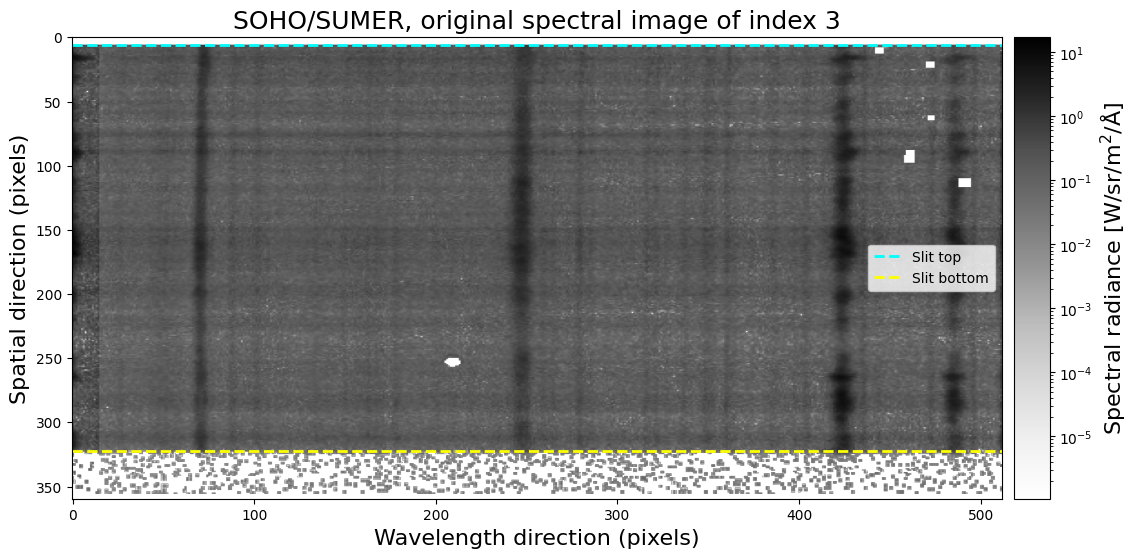

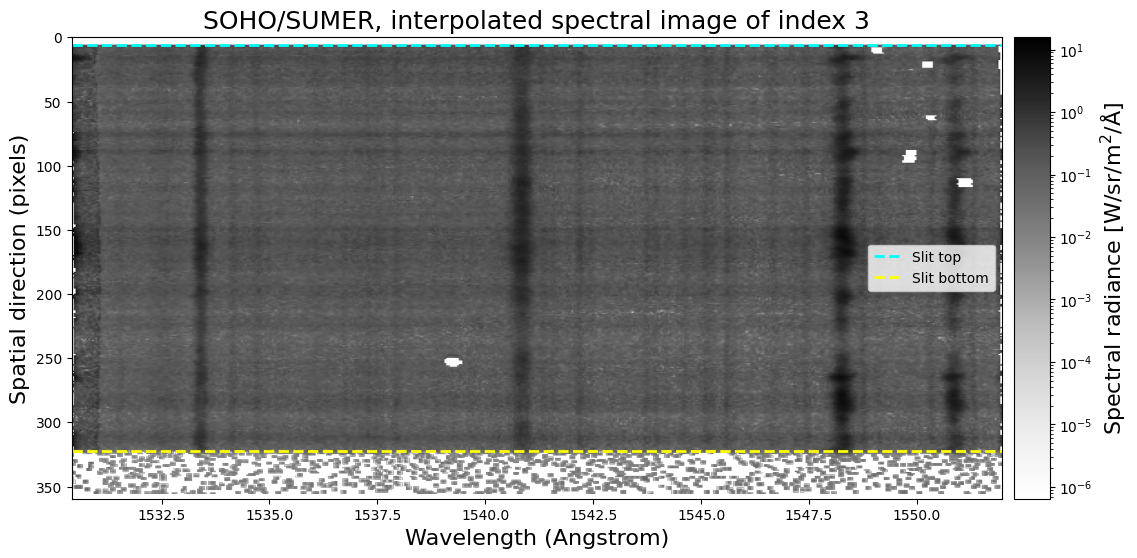

In [11]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(12, 6))
img = ax.imshow(spectral_image, cmap='Greys', aspect='auto', norm=LogNorm())
cax = fig.add_axes([0.91, 0.11, 0.03, 0.77])  # [left, bottom, width, height]
cbar = fig.colorbar(img, cax=cax)
cbar.set_label(r'Spectral radiance [W/sr/m$^2$/''\u212B]', fontsize=16)
ax.set_title(f'SOHO/SUMER, original spectral image of index {idx_spectral_image}', fontsize=18) 
ax.set_xlabel('Wavelength direction (pixels)', color='black', fontsize=16)
ax.set_ylabel('Spatial direction (pixels)', color='black', fontsize=16)
ax.axhline(y=slit_top_px, linestyle='--', color='cyan', linewidth=2, label='Slit top')
ax.axhline(y=slit_bottom_px, linestyle='--', color='yellow', linewidth=2, label='Slit bottom')
ax.legend(fontsize=10)
plt.show(block=False)


extent = [extent_reference_wavelength[0], extent_reference_wavelength[1], 359+0.5, 0-0.5]
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(12, 6))
img = ax.imshow(spectral_image_interpolated, cmap='Greys', aspect='auto', norm=LogNorm(), extent=extent)
cax = fig.add_axes([0.91, 0.11, 0.03, 0.77])  # [left, bottom, width, height]
cbar = fig.colorbar(img, cax=cax)
cbar.set_label(r'Spectral radiance [W/sr/m$^2$/''\u212B]', fontsize=16)
ax.set_title(f'SOHO/SUMER, interpolated spectral image of index {idx_spectral_image}', fontsize=18) 
ax.set_xlabel('Wavelength (Angstrom)', color='black', fontsize=16)
ax.set_ylabel('Spatial direction (pixels)', color='black', fontsize=16)
ax.axhline(y=slit_top_px, linestyle='--', color='cyan', linewidth=2, label='Slit top')
ax.axhline(y=slit_bottom_px, linestyle='--', color='yellow', linewidth=2, label='Slit bottom')
ax.legend(fontsize=10)
plt.show(block=False)

### Plot wavelength against the row indices for a selected column

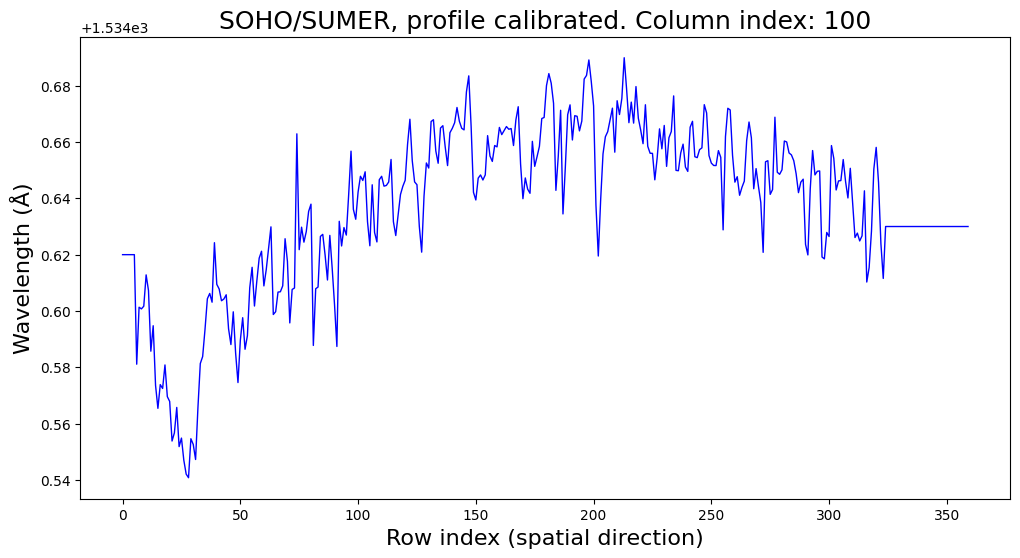

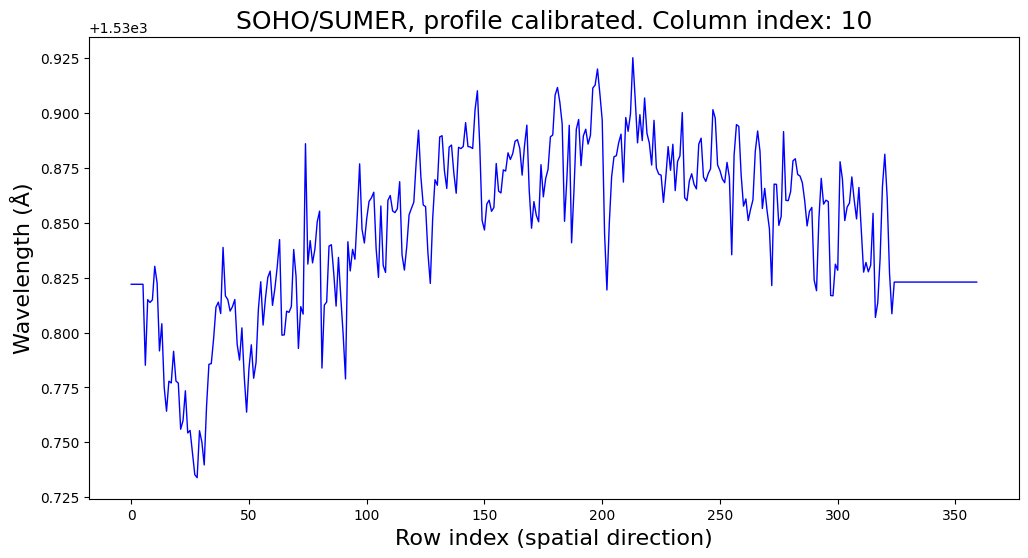

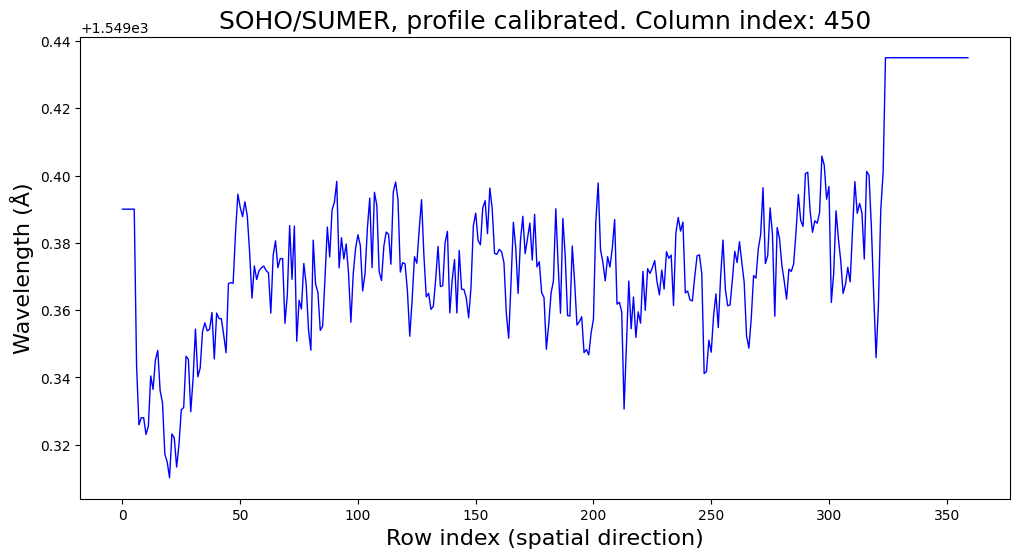

In [12]:
col_idx = 100
col_wavelength = np.array(pixelscale_list) * col_idx + np.array(pixelscale_intercept_list)
row_idx = np.arange(0,len(pixelscale_list))

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(12, 6))
ax.errorbar(x=row_idx, y=col_wavelength, color='blue', linewidth=1.)
ax.set_title(f'SOHO/SUMER, profile calibrated. Column index: {col_idx}', fontsize=18) 
ax.set_xlabel('Row index (spatial direction)', color='black', fontsize=16)
ax.set_ylabel('Wavelength (\u212B)', color='black', fontsize=16)
#ax.legend(fontsize=10)
plt.show(block=False)




col_idx = 10
col_wavelength = np.array(pixelscale_list) * col_idx + np.array(pixelscale_intercept_list)
row_idx = np.arange(0,len(pixelscale_list))

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(12, 6))
ax.errorbar(x=row_idx, y=col_wavelength, color='blue', linewidth=1.)
ax.set_title(f'SOHO/SUMER, profile calibrated. Column index: {col_idx}', fontsize=18) 
ax.set_xlabel('Row index (spatial direction)', color='black', fontsize=16)
ax.set_ylabel('Wavelength (\u212B)', color='black', fontsize=16)
#ax.legend(fontsize=10)
plt.show(block=False)





col_idx = 450
col_wavelength = np.array(pixelscale_list) * col_idx + np.array(pixelscale_intercept_list)
row_idx = np.arange(0,len(pixelscale_list))

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(12, 6))
ax.errorbar(x=row_idx, y=col_wavelength, color='blue', linewidth=1.)
ax.set_title(f'SOHO/SUMER, profile calibrated. Column index: {col_idx}', fontsize=18) 
ax.set_xlabel('Row index (spatial direction)', color='black', fontsize=16)
ax.set_ylabel('Wavelength (\u212B)', color='black', fontsize=16)
#ax.legend(fontsize=10)
plt.show(block=False)


### Apply functions above to all the rows of an spectral image

In [13]:
def calibration_spectral_image_interpolate_list(row_reference, spectral_image_list, spectral_image_unc_list, slope_list, slope_unc_list, intercept_list, intercept_unc_list): 
    """
    Interpolate all the rows of all spectral image.
    """
    def linear_func(x, m, b): return m*x+b
    def linear_func_uncertainty(x, dx, m, dm, b, db): return np.sqrt( (m*dx)**2 + (x*dm)**2 + db**2 )
    
    from tqdm import tqdm
    
    N_rows, N_cols = spectral_image_list[0].shape
    reference_wavelength = linear_func(x=np.arange(0,N_cols), m=slope_list[row_reference], b=intercept_list[row_reference])
    unc_reference_wavelength = linear_func_uncertainty(x=np.arange(0,N_cols), dx=np.zeros(N_cols), m=slope_list[row_reference], dm=slope_unc_list[row_reference], b=intercept_list[row_reference], db=intercept_unc_list[row_reference])
    px_half = slope_list[row_reference]/2 # half of the pixel scale
    extent_reference_wavelength = [reference_wavelength[0]-px_half, reference_wavelength[-1]+px_half] #use it for the 2D plots (extent)
    
    spectral_image_interpolated_list, spectral_image_unc_interpolated_list = [],[]
    for i_img in tqdm(range(len(spectral_image_list)), desc="Interpolating", unit="image"): #tqdm adds a progress bar here
        spectral_image_interpolated, spectral_image_unc_interpolated, reference_wavelength_i, unc_reference_wavelength_i, extent_reference_wavelength_i = calibration_spectral_image_interpolate(row_reference=row_reference, spectral_image=spectral_image_list[i_img], spectral_image_unc=spectral_image_unc_list[i_img], slope_list=slope_list, slope_unc_list=slope_unc_list, intercept_list=intercept_list, intercept_unc_list=intercept_unc_list)
        spectral_image_interpolated_list.append(spectral_image_interpolated)
        spectral_image_unc_interpolated_list.append(spectral_image_unc_interpolated)
        
    return [spectral_image_interpolated_list, spectral_image_unc_interpolated_list, reference_wavelength, unc_reference_wavelength, extent_reference_wavelength] #the reference_wavelength is a 1D-array with the calibrated wavelengths corresponding to the the reference row. #extent_reference_wavelength is used in the 2D-plots later


# Interpolate all spectral images

In [14]:
spectral_image_interpolated_list, spectral_image_unc_interpolated_list, reference_wavelength, unc_reference_wavelength, extent_reference_wavelength = calibration_spectral_image_interpolate_list(row_reference=row_reference, spectral_image_list=spectral_image_list, spectral_image_unc_list=spectral_image_unc_list, slope_list=pixelscale_list, slope_unc_list=pixelscale_unc_list, intercept_list=pixelscale_intercept_list, intercept_unc_list=pixelscale_intercept_unc_list)


Interpolating:   0%|                                 | 0/240 [00:00<?, ?image/s]/tmp/ipykernel_9328/2873059014.py:46: UserWarning: Warning: converting a masked element to nan.
  y_unc_interp = np.array(y_unc_interp_list)
Interpolating: 100%|███████████████████████| 240/240 [04:14<00:00,  1.06s/image]


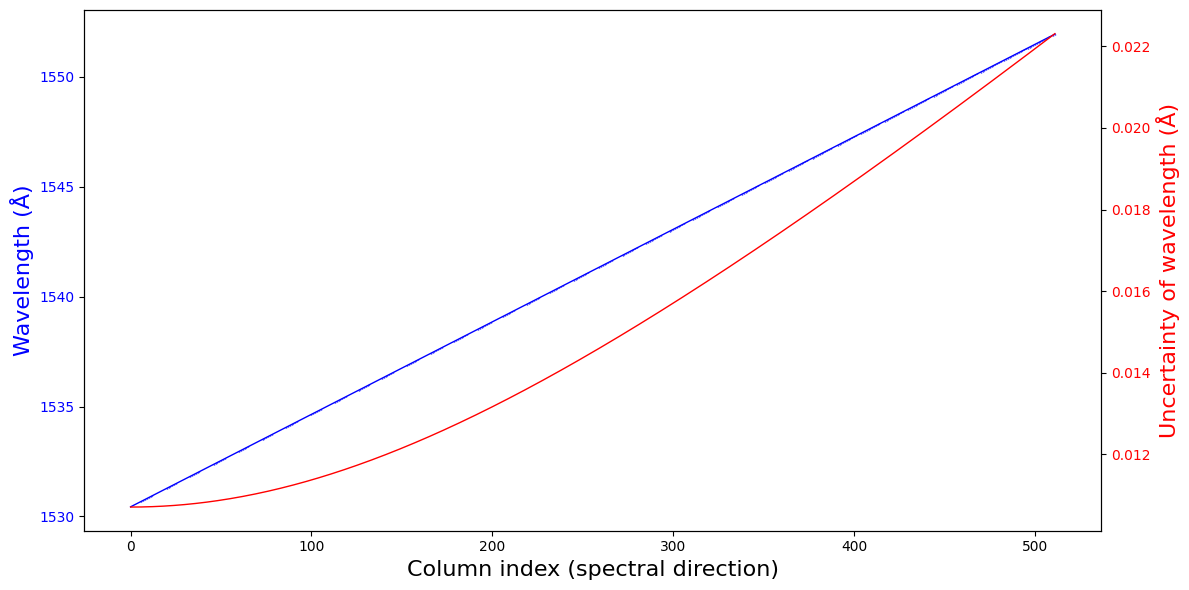

In [15]:
fig, ax1 = plt.subplots(nrows=1, ncols=1, figsize=(12, 6))

# Primary y-axis (left): row index vs wavelength with errors
ax1.errorbar(x=np.arange(len(reference_wavelength)), y=reference_wavelength, yerr=unc_reference_wavelength, color='blue', linewidth=1.)
ax1.set_xlabel('Column index (spectral direction)', color='black', fontsize=16)
ax1.set_ylabel('Wavelength (Å)', color='blue', fontsize=16)
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_title('', fontsize=18)

# Secondary y-axis (right): wavelength vs uncertainty
ax2 = ax1.twinx()
ax2.errorbar(x=np.arange(len(reference_wavelength)), y=unc_reference_wavelength, color='red', linewidth=1.)
ax2.set_ylabel('Uncertainty of wavelength (Å)', color='red', fontsize=16)
ax2.tick_params(axis='y', labelcolor='red')

plt.tight_layout()
plt.show(block=False)

### Average all spectral images interpolated, and plot it

In [16]:
spectral_image_interpolated_average, spectral_image_unc_interpolated_average = SUMERraster_average_spectra(sumer_data_list=spectral_image_interpolated_list, sumer_data_unc_list=spectral_image_unc_interpolated_list)


/tmp/ipykernel_9328/502670978.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=10)


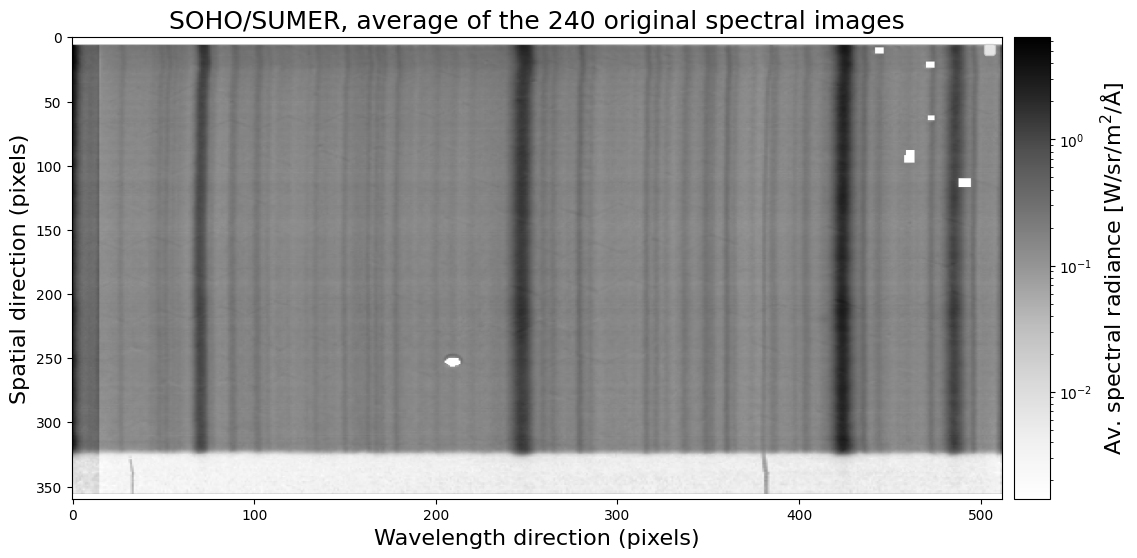

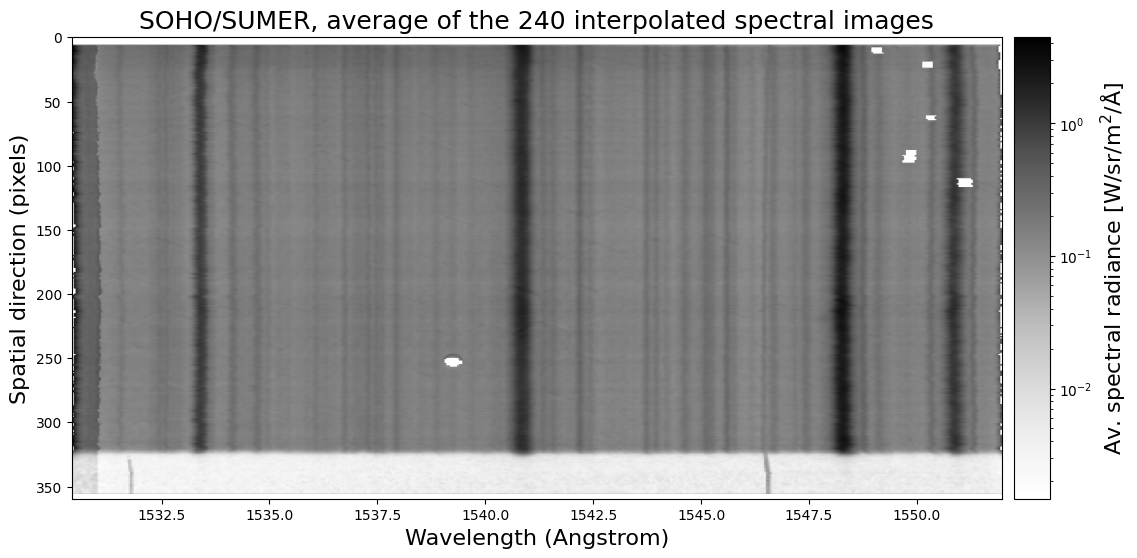

/tmp/ipykernel_9328/502670978.py:36: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=10)


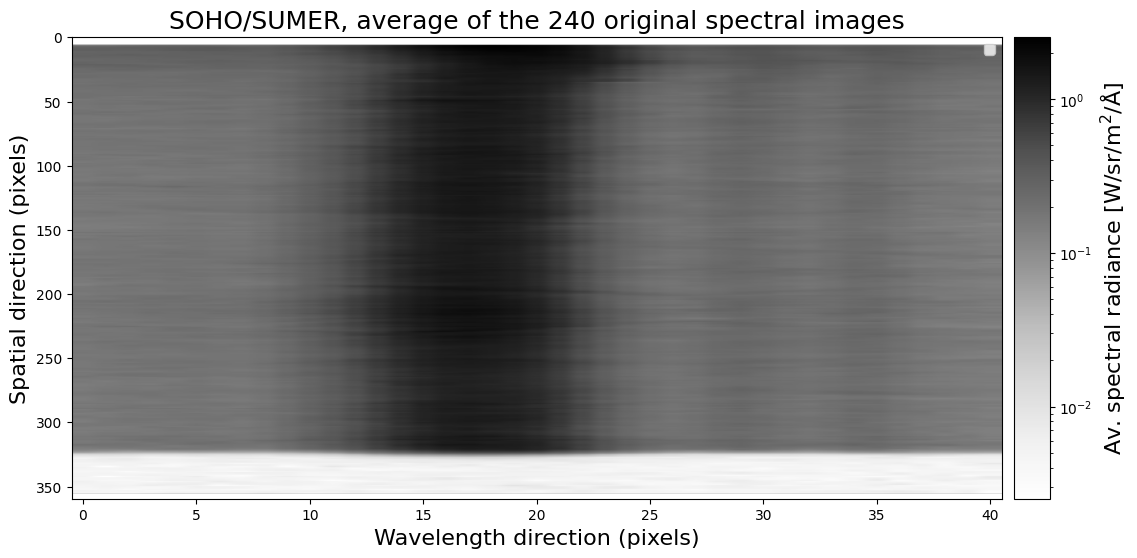

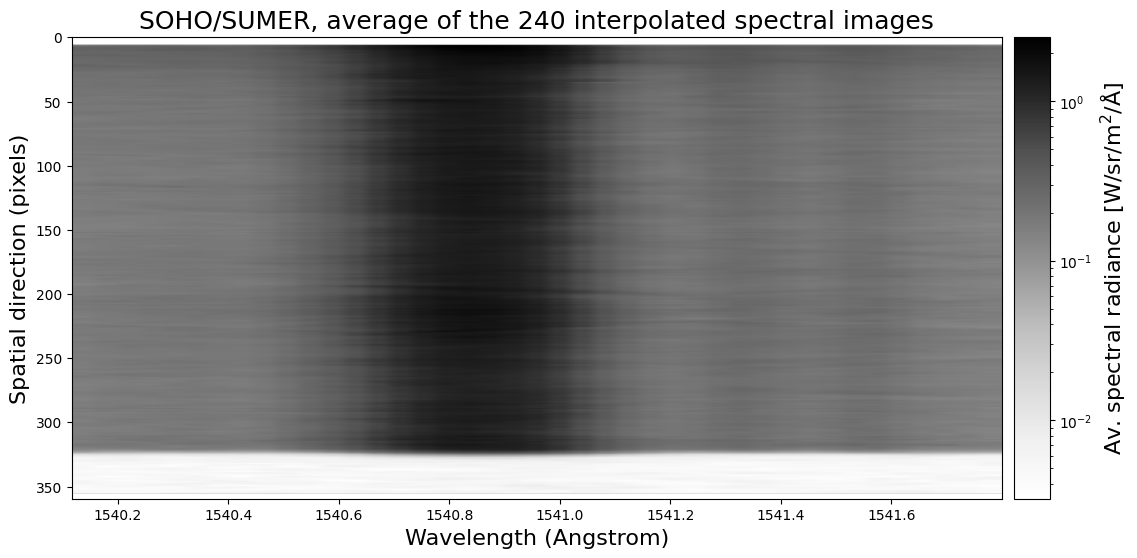

In [17]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(12, 6))
img = ax.imshow(spectral_image_average, cmap='Greys', aspect='auto', norm=LogNorm())
cax = fig.add_axes([0.91, 0.11, 0.03, 0.77])  # [left, bottom, width, height]
cbar = fig.colorbar(img, cax=cax)
cbar.set_label(r'Av. spectral radiance [W/sr/m$^2$/''\u212B]', fontsize=16)
ax.set_title(f'SOHO/SUMER, average of the 240 original spectral images', fontsize=18) 
ax.set_xlabel('Wavelength direction (pixels)', color='black', fontsize=16)
ax.set_ylabel('Spatial direction (pixels)', color='black', fontsize=16)
ax.legend(fontsize=10)
plt.show(block=False)


extent = [extent_reference_wavelength[0], extent_reference_wavelength[1], 359+0.5, 0-0.5]
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(12, 6))
img = ax.imshow(spectral_image_interpolated_average, cmap='Greys', aspect='auto', norm=LogNorm(), extent=extent)
cax = fig.add_axes([0.91, 0.11, 0.03, 0.77])  # [left, bottom, width, height]
cbar = fig.colorbar(img, cax=cax)
cbar.set_label(r'Av. spectral radiance [W/sr/m$^2$/''\u212B]', fontsize=16)
ax.set_title(f'SOHO/SUMER, average of the 240 interpolated spectral images', fontsize=18) 
ax.set_xlabel('Wavelength (Angstrom)', color='black', fontsize=16)
ax.set_ylabel('Spatial direction (pixels)', color='black', fontsize=16)
plt.show(block=False)




col1, col2 = [230, 270]
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(12, 6))
img = ax.imshow(spectral_image_average[:, col1:col2+1], cmap='Greys', aspect='auto', norm=LogNorm())
cax = fig.add_axes([0.91, 0.11, 0.03, 0.77])  # [left, bottom, width, height]
cbar = fig.colorbar(img, cax=cax)
cbar.set_label(r'Av. spectral radiance [W/sr/m$^2$/''\u212B]', fontsize=16)
ax.set_title(f'SOHO/SUMER, average of the 240 original spectral images', fontsize=18) 
ax.set_xlabel('Wavelength direction (pixels)', color='black', fontsize=16)
ax.set_ylabel('Spatial direction (pixels)', color='black', fontsize=16)
ax.legend(fontsize=10)
plt.show(block=False)


extent = [reference_wavelength[col1], reference_wavelength[col2], 359+0.5, 0-0.5]
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(12, 6))
img = ax.imshow(spectral_image_interpolated_average[:, col1:col2+1], cmap='Greys', aspect='auto', norm=LogNorm(), extent=extent)
cax = fig.add_axes([0.91, 0.11, 0.03, 0.77])  # [left, bottom, width, height]
cbar = fig.colorbar(img, cax=cax)
cbar.set_label(r'Av. spectral radiance [W/sr/m$^2$/''\u212B]', fontsize=16)
ax.set_title(f'SOHO/SUMER, average of the 240 interpolated spectral images', fontsize=18) 
ax.set_xlabel('Wavelength (Angstrom)', color='black', fontsize=16)
ax.set_ylabel('Spatial direction (pixels)', color='black', fontsize=16)
plt.show(block=False)

# Remove the upper slit_top_px rows from all the spectral images

In [36]:
spectral_image_interpolated_croplat_list = [spectral_image_[slit_top_px:slit_bottom_px+1, :] for spectral_image_ in spectral_image_interpolated_list]
spectral_image_unc_interpolated_croplat_list = [spectral_image_unc_[slit_top_px:slit_bottom_px+1, :] for spectral_image_unc_ in spectral_image_unc_interpolated_list]

/tmp/ipykernel_9328/2058466346.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=10)


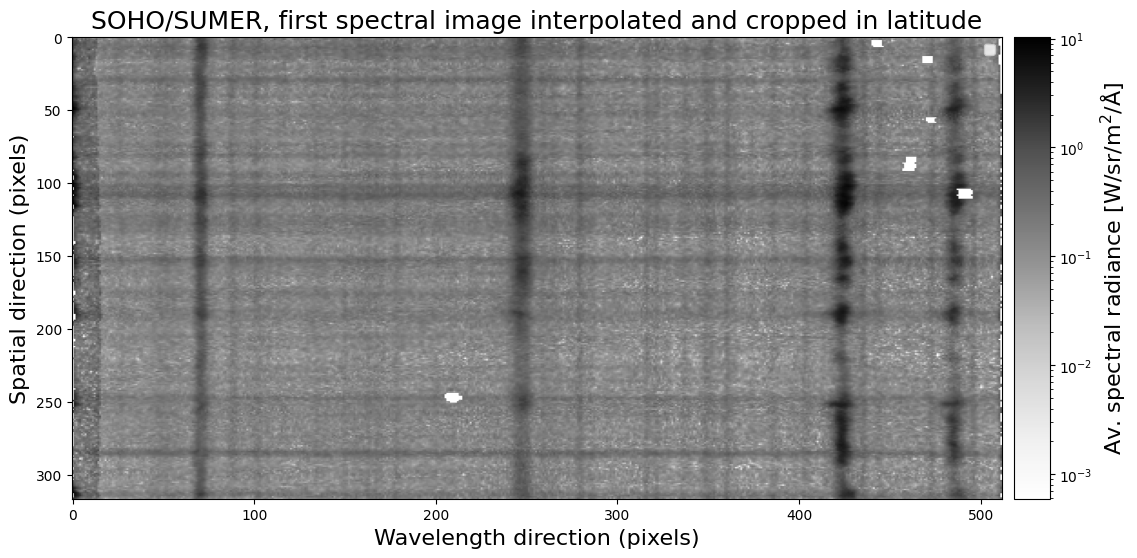

/tmp/ipykernel_9328/2058466346.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=10)


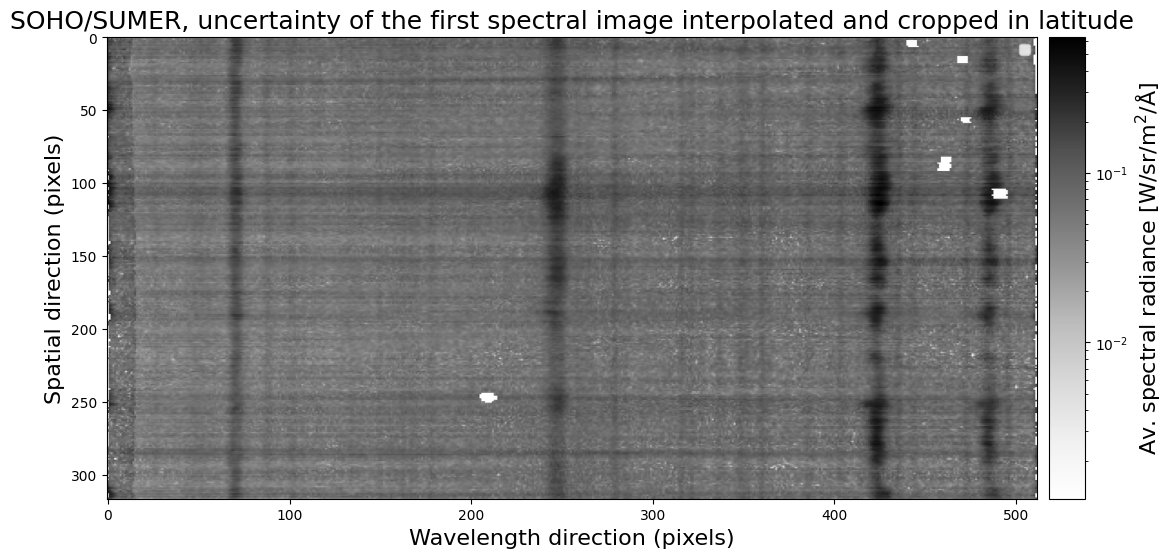

In [38]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(12, 6))
img = ax.imshow(spectral_image_interpolated_croplat_list[0], cmap='Greys', aspect='auto', norm=LogNorm())
cax = fig.add_axes([0.91, 0.11, 0.03, 0.77])  # [left, bottom, width, height]
cbar = fig.colorbar(img, cax=cax)
cbar.set_label(r'Av. spectral radiance [W/sr/m$^2$/''\u212B]', fontsize=16)
ax.set_title(f'SOHO/SUMER, first spectral image interpolated and cropped in latitude', fontsize=18) 
ax.set_xlabel('Wavelength direction (pixels)', color='black', fontsize=16)
ax.set_ylabel('Spatial direction (pixels)', color='black', fontsize=16)
ax.legend(fontsize=10)
plt.show(block=False)



fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(12, 6))
img = ax.imshow(spectral_image_unc_interpolated_croplat_list[0], cmap='Greys', aspect='auto', norm=LogNorm())
cax = fig.add_axes([0.91, 0.11, 0.03, 0.77])  # [left, bottom, width, height]
cbar = fig.colorbar(img, cax=cax)
cbar.set_label(r'Av. spectral radiance [W/sr/m$^2$/''\u212B]', fontsize=16)
ax.set_title(f'SOHO/SUMER, uncertainty of the first spectral image interpolated and cropped in latitude', fontsize=18) 
ax.set_xlabel('Wavelength direction (pixels)', color='black', fontsize=16)
ax.set_ylabel('Spatial direction (pixels)', color='black', fontsize=16)
ax.legend(fontsize=10)
plt.show(block=False)

# Save interpolated data on a file .npz

In [40]:
np.savez_compressed('../auxiliar_functions/wcal4__spectral_image_list_intepolated_and_wavelength___.npz', spectral_image_interpolated_list=spectral_image_interpolated_list, spectral_image_unc_interpolated_list=spectral_image_unc_interpolated_list, spectral_image_interpolated_croplat_list=spectral_image_interpolated_croplat_list, spectral_image_unc_interpolated_croplat_list=spectral_image_unc_interpolated_croplat_list, reference_wavelength=reference_wavelength, unc_reference_wavelength=unc_reference_wavelength, row_reference=row_reference)

# In order to load this data from another file (or this file), you have to do this:
"""
data_loaded = np.load('spectral_image_list_intepolated_and_wavelength___.npz', allow_pickle=True)
spectral_image_interpolated_list_loaded = data_loaded['spectral_image_interpolated_list']
spectral_image_unc_interpolated_list_loaded = data_loaded['spectral_image_unc_interpolated_list']
spectral_image_interpolated_croplat_list_loaded = data_loaded['spectral_image_interpolated_croplat_list']
spectral_image_unc_interpolated_croplat_list_loaded = data_loaded['spectral_image_unc_interpolated_croplat_list']
reference_wavelength_loaded = data_loaded['reference_wavelength']          # scalar (0‑d array; use a_loaded.item() for Python float)
unc_reference_wavelength_loaded = data_loaded['unc_reference_wavelength'] 
row_reference_loaded = int(data_loaded['row_reference'])        # becomes a NumPy array or object array, so I conver it to integer again
"""
""

''